<a href="https://colab.research.google.com/github/ShikhaChauhan20/House_Price_PridictionModel/blob/main/HousePricePredictionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np


In [7]:
df=pd.read_csv('housing.csv')

Structural details

In [8]:
print("Dataset Overview")
print(f"Total Rows(properties): {df.shape[0]}")
print(f"Total columns(features): {df.shape[1]}")
print("_"*30)

Dataset Overview
Total Rows(properties): 180
Total columns(features): 6
______________________________


Checking columns ,datatypes and missing value

In [9]:
print("\n=== Column information & missing values ===")
info_df=pd.DataFrame({
    'Data Type' : df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum()/df.shape[0])*100
})
print(info_df)
print("_"*30)


=== Column information & missing values ===
                Data Type  Non-Null Count  Missing Values  Missing %
Appartment_type    object             180               0        0.0
Price_per_sq_ft    object             180               0        0.0
Area                int64             180               0        0.0
Price               int64             180               0        0.0
Status             object             180               0        0.0
Location           object             180               0        0.0
______________________________


In [10]:
print("\n=== First 5 rows===")
df.head()

print("\n ===Unique values in apartment type===")
print(df['Appartment_type'].unique())

print("\n ===Unique values in status===")
print(df['Status'].unique())

print ("\n=== Top 10 common locations === ")
print(df['Location'].value_counts().head(10))



=== First 5 rows===

 ===Unique values in apartment type===
['3 BHK Apartment' '3 BHK Independent House' '3 BHK Independent Floor'
 'Residential Plot' '2 BHK Apartment' '2 BHK Independent House'
 '3 BHK Villa' '9 BHK Independent House' '1 BHK Apartment' '4 BHK Villa'
 '2 BHK Apartment ' '3 BHK Apartment ' 'Residential Plot '
 '4 BHK Independent House' '4 BHK Apartment ' '1 RK Studio Apartment '
 '8 BHK Independent House' '1 BHK Apartment ' '2 BHK Independent House '
 '1 BHK Independent Floor' '6 BHK Independent House'
 '2 BHK Independent Floor' '4 BHK Apartment' '4 BHK Independent Floor']

 ===Unique values in status===
['Ready to move' 'Under Construction' 'Resale' 'New']

=== Top 10 common locations === 
Location
Govind Vihar, Dehradun      23
Kulhan, Dehradun            11
Jhanda Mohalla, Dehradun    10
Majra, Dehradun             10
Pondha, Dehradun             9
Badripur, Dehradun           8
Malsi, Dehradun              6
Aman Vihar, Dehradun         6
Rajpur, Dehradun          

In [11]:
# creating a copy of dataframes to keep the original safe
df_clean=df.copy()

#1 cleaning "price_per_sq-ft" (remove commas and convert to float/int)
df_clean['Price_per_sq_ft'] = df_clean['Price_per_sq_ft'].str.replace(',','').astype(float)

#2 extract bhk number from 'appartment type' using regex
#this looks for digits (\d+) right befor the word 'bhk'
df_clean['BHK']= df_clean['Appartment_type'].str.extract(r'(\d+)').astype(float)

#3 extrat the property type (apartment ,house ,floor)
#we replace the bhk part to extract just the text that follows it
df_clean['Property_Type']=df_clean['Appartment_type'].str.replace(r'\d+\s*BHK\s*', '',regex=True).str.strip()

#4 clean 'location' (extract  just the neighborhood name before the comma)
df_clean['Neighborhood']=df_clean['Location'].apply(lambda x:x.split(',')[0].strip())

#5 Newly engineered features!
print("===Clean Data Preview===")
print(df_clean[['Appartment_type','BHK','Property_Type','Price_per_sq_ft','Neighborhood', 'Price']].head())
print("\n===Cleaned Data Types===")
print(df_clean.dtypes)

===Clean Data Preview===
           Appartment_type  BHK      Property_Type  Price_per_sq_ft  \
0          3 BHK Apartment  3.0          Apartment           7729.0   
1  3 BHK Independent House  3.0  Independent House           4889.0   
2          3 BHK Apartment  3.0          Apartment           3000.0   
3  3 BHK Independent Floor  3.0  Independent Floor          15000.0   
4  3 BHK Independent House  3.0  Independent House           4166.0   

   Neighborhood     Price  
0  Patthri Bagh   8000000  
1    Aman Vihar   7500000  
2  Tanda Ujjain   3000000  
3   Ganga Nagar  30000000  
4     Modipuram   6500000  

===Cleaned Data Types===
Appartment_type     object
Price_per_sq_ft    float64
Area                 int64
Price                int64
Status              object
Location            object
BHK                float64
Property_Type       object
Neighborhood        object
dtype: object


In [14]:
#1 selecting the features we want to use to predict the price
# droping columns - no longer needed (like the original text columns - cleaned)
features_to_encode=['BHK','Property_Type','Status','Neighborhood','Area','Price_per_sq_ft']
X_raw = df_clean[features_to_encode]

#2 performing one hot encoding on the text features
# Pandas automatically detects 'object' columns and expand them into 0s and 1s
X=pd.get_dummies(X_raw, columns=['Property_Type','Status','Neighborhood'], drop_first=True)

#3 Final Mathmatical Matrix
print("===Final Matrix===")
print(f"Rows: {X.shape[0]} , Columns(Features) : {X.shape[1]}")

print(X.head(3))

===Final Matrix===
Rows: 180 , Columns(Features) : 65
   BHK  Area  Price_per_sq_ft  Property_Type_Apartment  \
0  3.0  1035           7729.0                     True   
1  3.0  1534           4889.0                    False   
2  3.0  1000           3000.0                     True   

   Property_Type_Independent Floor  Property_Type_Independent House  \
0                            False                            False   
1                            False                             True   
2                            False                            False   

   Property_Type_Residential Plot  Property_Type_Villa  Status_Ready to move  \
0                           False                False                  True   
1                           False                False                  True   
2                           False                False                  True   

   Status_Resale  ...  Neighborhood_Rajender Nagar  Neighborhood_Rajpur  \
0          False  ...           

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. emptyy space (NaN) fixing here
X['BHK'] = X['BHK'].fillna(0)
X = X.fillna(X.median())

print("✅ NaNs fixed. Training the model now...")
print("-" * 50)

# 2. data split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model train and predict
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== 📉 Model Performance Metrics ===")
print(f"Mean Absolute Error (MAE): Rs. {mae:,.2f}")
print(f"R² Score (Accuracy Metric): {r2:.4f}")

✅ NaNs fixed. Training the model now...
--------------------------------------------------
=== 📉 Model Performance Metrics ===
Mean Absolute Error (MAE): Rs. 2,247,942.24
R² Score (Accuracy Metric): 0.7439


In [23]:
from sklearn.ensemble import RandomForestRegressor

#intializing the random forest model
#n_estimators=100 means it will train 100 individula decison trees and average them
rf_model=RandomForestRegressor(n_estimators=100, random_state=42)

#train the model using the EXACT same scaled data
rf_model.fit(X_train_scaled, y_train)

 #making predivtions
y_pred_rf=rf_model.predict(X_test_scaled)

mae_rf=mean_absolute_error(y_test, y_pred_rf)
r2_rf=r2_score(y_test, y_pred_rf)

print("=== 📉 Random Forest Model Performance Metrics ===")
print(f"Mean Absolute Error (MAE): Rs. {mae_rf:,.2f}")
print(f"R² Score (Accuracy Metric): {r2_rf:.4f}")

# comparing it directly to linear regression baseline
print("\n === comparison ===")
print(f"Linear Regression R^2: {r2:4f} | Random forest R^2: {r2_rf:.4f}")
print(f"Linear Regression MAE: {mae_rf:,.2f} | Random Forest MAE: Rs. {mae_rf:,.2f}")



=== 📉 Random Forest Model Performance Metrics ===
Mean Absolute Error (MAE): Rs. 1,466,473.12
R² Score (Accuracy Metric): 0.8689

 === comparison ===
Linear Regression R^2: 0.743893 | Random forest R^2: 0.8689
Linear Regression MAE: 1,466,473.12 | Random Forest MAE: Rs. 1,466,473.12


In [24]:
# 1 lets create a brand new house profile using a row template from our matrix
# i am copying the the rwo of x to get the structure right
mock_house=X.iloc[[0]].copy()

# 2 modifying its core features to test the model
# lets say we wnt to predict a 4 bhk property with a huge 2500sq ft
mock_house['BHK']=4.0
mock_house['Area']=2500
mock_house['Price_per_sq_ft']= 8500.0 #assumed cost per sq ft

# 3 pass this house through the EXACT same scaler we used for training
mock_house_scaled = scaler.transform(mock_house)

# 4 using random froest model tp predict the final price
predicted_price=rf_model.predict(mock_house_scaled)[0]

print("===Real time prediction===")
print(f"Predicted Price for this custom property: Rs. {predicted_price :,.2f}")
print(f"In Lakhs/Crores: Rs. {predicted_price / 100000:.2f} Lakhs")

===Real time prediction===
Predicted Price for this custom property: Rs. 18,085,000.00
In Lakhs/Crores: Rs. 180.85 Lakhs


=== Top 10 impactful features ===
Price_per_sq_ft: 70.41% impact
Area: 17.45% impact
BHK: 6.85% impact
Neighborhood_Garhi Cantt: 0.81% impact
Property_Type_Independent House: 0.55% impact
Property_Type_Villa: 0.54% impact
Neighborhood_Govind Vihar: 0.41% impact
Status_Resale: 0.38% impact
Neighborhood_Kishanpur: 0.28% impact
Neighborhood_Majra: 0.24% impact


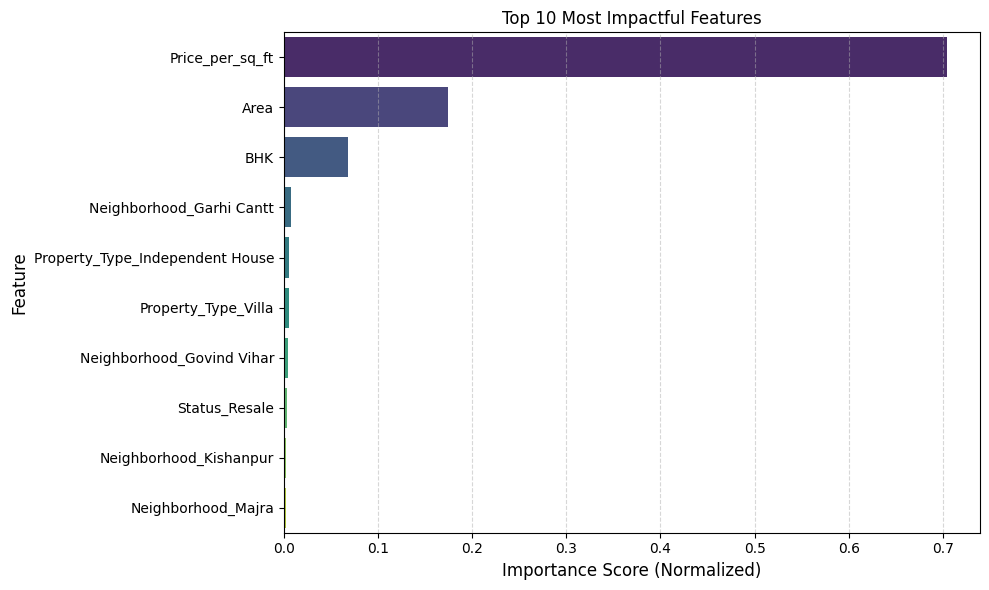

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# 1 get features importances from our trained random forestmodel
importances = rf_model.feature_importances_

# 2 match them up with the column names from our feature matrix X
feature_names=X.columns

# 3 create a pandas dataframe to easily sort and filter them
forest_importances= pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance',ascending=False) #sort from high to low

#take only the top 10 mont impactful features
top10_features = forest_importances.head(10)

#plot using matplotlib and seaborn
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top10_features,
    palette='viridis',
    hue='Feature',
    legend = False
)

# customizing the chart look
plt.title('Top 10 Most Impactful Features')
plt.xlabel('Importance Score (Normalized)',fontsize=12)
plt.ylabel('Feature',fontsize=12)
plt.grid(axis='x', linestyle='--' , alpha =0.5)

plt.tight_layout()
plt.show

print ("=== Top 10 impactful features ===")
for index, row in top10_features.iterrows():
    print(f"{row['Feature']}: {row['Importance']*100:.2f}% impact")

